**Table of contents**<a id='toc0_'></a>    
- [Question 1 - Data Analysis](#toc1_)    
  - [i) Counting Examples](#toc1_1_)    
  - [ii) Protein Expression Histograms](#toc1_2_)    
  - [iii) Image Preprocessing](#toc1_3_)    
  - [iv) Channel Correlation with CD11b Expression](#toc1_4_)    
  - [v) Blue vs H Channels](#toc1_5_)    
- [Question 2](#toc2_)    
  - [i) Feature Selection](#toc2_1_)    
    - [PCA On all RGB Channels](#toc2_1_1_)    
    - [PCA on all HED channels](#toc2_1_2_)    
    - [Mean and Variance](#toc2_1_3_)    
    - [Histogram of Gradients](#toc2_1_4_)    
    - [PCA with HoG](#toc2_1_5_)    
  - [Regression Models](#toc2_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [22]:
!pip install tqdm # for progress bars
!pip install seaborn # for barplot
!pip install opencv-python # for image manipulation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 131.4 MB/s eta 0:00:0000:0100:01


# <a id='toc1_'></a>[Question 1 - Data Analysis](#toc0_)

## <a id='toc1_1_'></a>[i) Counting Examples](#toc0_)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')

df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
train_specimens = ['B1', 'C1', 'D1']
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']

Let's first separate the training and test data. 

In [38]:
df_train = df.loc[df['specimen_id'].isin(train_specimens)]
df_test = df.loc[df['specimen_id'] == 'A1']

df_train['CD11b'].describe()

count    7027.000000
mean       -1.584007
std         1.481296
min        -4.782092
25%        -2.794762
50%        -1.180678
75%        -0.321114
max         1.761779
Name: CD11b, dtype: float64

The number of spots of each specimen in the training set are given below:

In [4]:
df_train.groupby('specimen_id')['specimen_id'].value_counts()

specimen_id
B1    1145
C1    4129
D1    1753
Name: count, dtype: int64

## <a id='toc1_2_'></a>[ii) Protein Expression Histograms](#toc0_)

Text(0.5, 0.98, 'CD11b Expression Values by Specimen')

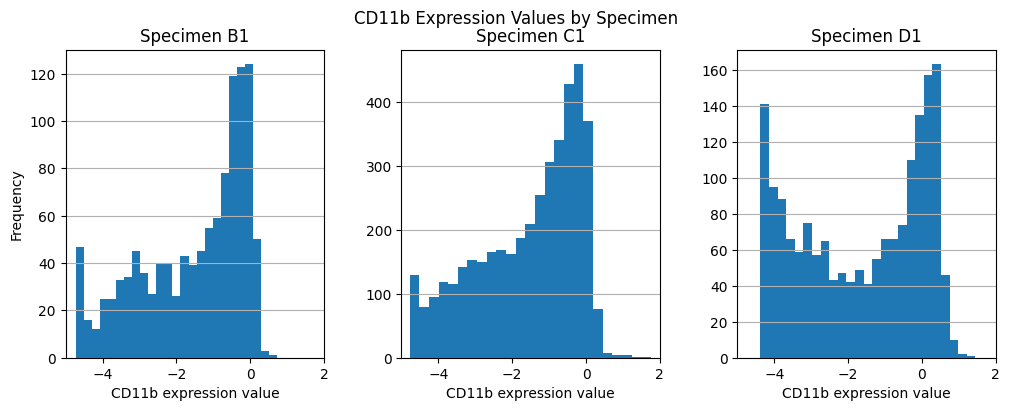

In [5]:
fig, axes = plt.subplots(1, 3)
fig.set_figheight(4)
fig.set_figwidth(12)

for i, ax in enumerate(axes.flatten()):
    specimen = train_specimens[i]
    df_train.loc[df_train['specimen_id'] == specimen].hist('CD11b', ax=ax, bins=25)
    ax.set_title(f"Specimen {specimen}")

    ax.set_xlabel('CD11b expression value')
    if (i == 0):
        ax.set_ylabel('Frequency')
    ax.set_xlim((-5, 2))
    #ax.set_ylim((0, 1050)) # If we want all histograms to be on the same scale
    ax.grid(visible=False, axis='x')
    
fig.suptitle('CD11b Expression Values by Specimen')


We notice that specimen B1 and C1 have similar distributions of the expression value of protein CD11b, with peaks at around 0 and tails to the left down to -5. Specimen D1 has two peaks at -4 and 0. 

Text(0.5, 0.98, 'CD11b Expression Values by Specimen')

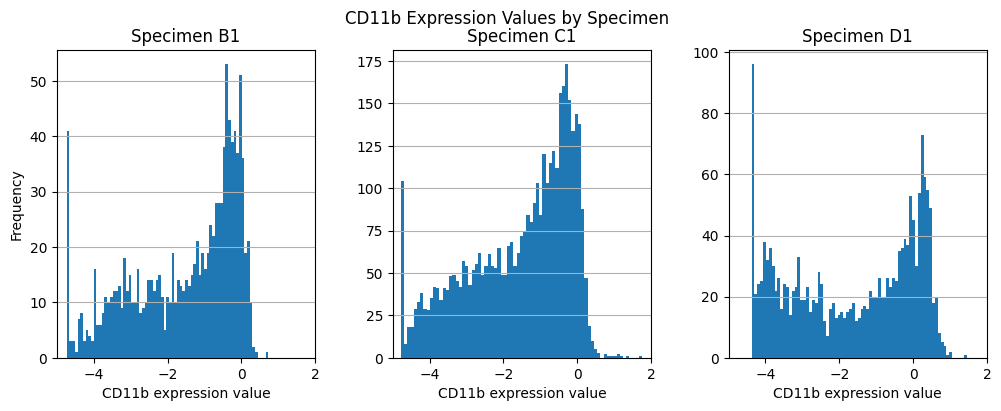

In [6]:
fig, axes = plt.subplots(1, 3)
fig.set_figheight(4)
fig.set_figwidth(12)

for i, ax in enumerate(axes.flatten()):
    specimen = train_specimens[i]
    df_train.loc[df_train['specimen_id'] == specimen].hist('CD11b', ax=ax, bins=75)
    ax.set_title(f"Specimen {specimen}")

    ax.set_xlabel('CD11b expression value')
    if (i == 0):
        ax.set_ylabel('Frequency')
    ax.set_xlim((-5, 2))
    #ax.set_ylim((0, 1050)) # If we want all histograms to be on the same scale
    ax.grid(visible=False, axis='x')
    
fig.suptitle('CD11b Expression Values by Specimen')

If we plot using more bins, we also notice that all three specimen have a peak at a very specific value on the left. This is interesting because there appear to be no expression values to the left of these peaks. 

In [7]:
df_train[['specimen_id', 'CD11b']].value_counts()

specimen_id  CD11b    
C1           -4.782092    104
D1           -4.376121     90
B1           -4.731601     40
C1           -4.402024      2
             -0.155368      1
                         ... 
             -2.256882      1
             -2.259379      1
             -2.261223      1
             -2.261946      1
             -2.240232      1
Name: count, Length: 6795, dtype: int64

We can see the peaks in the above value counts. The frequency peaks are at very specific values, whereas all (except one) other values have a frequency of 1. Plus, there are no values below the peaks. One possible explanation for this suggests that maybe originally there were values below the peaks, but they were for some reason all grouped into that one peak value. 

## <a id='toc1_3_'></a>[iii) Image Preprocessing](#toc0_)

In [42]:
image_folder = '/content/patches_256/'
from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from skimage.color import rgb2gray, rgba2rgb, rgb2hed
from skimage.io import imread
from skimage.util import img_as_ubyte
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import os
import glob

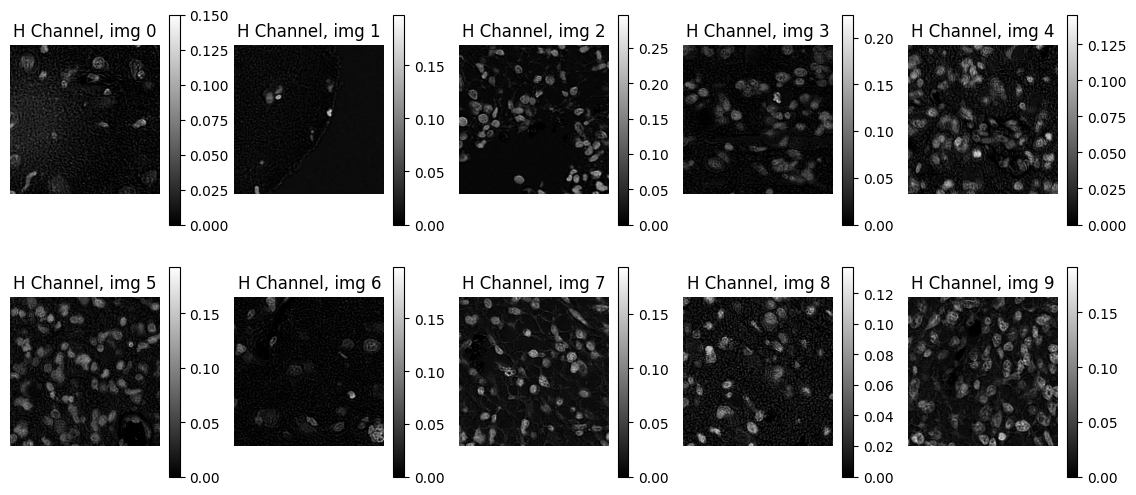

In [9]:
training_image_paths = glob.glob(os.getcwd()+image_folder+'[BCD]*.png')

# We'll use 10 random images
random_indices = np.random.choice(range(len(training_image_paths)), size=10, replace=False)
plt.figure(figsize=[14, 6])
for i, index in enumerate(random_indices):
    I = imread(training_image_paths[i])
    if I.shape[2] == 4: # It's an RGBA image
        I = rgba2rgb(I)
    I_hed = rgb2hed(I)
    I_h = I_hed[:,:,0]; 
    plt.subplot(2, 5, i+1)
    plt.imshow(I_h,cmap='gray');  
    plt.colorbar();  
    plt.title(f'H Channel, img {i}')
    plt.axis('off')
plt.show()

## <a id='toc1_4_'></a>[iv) Channel Correlation with CD11b Expression](#toc0_)

In [10]:
from tqdm import tqdm

training_images = {}
for path in tqdm(training_image_paths):
    image_id = os.path.splitext(os.path.basename(path))[0]
    # We don't care about the image if it doesn't appear in the CSV
    if image_id not in df_train.index:
        continue
    I = plt.imread(path)
    if I.shape[2] == 4: # It's an RGBA image
        I = rgba2rgb(I)
    training_images[path] = I

n_train = len(training_images)

100%|██████████| 8453/8453 [00:19<00:00, 439.45it/s]


In [ ]:
average_hs = []
average_bs = []
average_es = []
cd11b_values = []
specimens = []

for path in tqdm(training_images.keys()):
    image_id = os.path.splitext(os.path.basename(path))[0]
    I = training_images[path]

    row = df_train.loc[image_id]
    cd11b_values.append(row['CD11b'])
    specimens.append(row['specimen_id'])

    I_b = I[:,:,2]
    I_hed = rgb2hed(I)
    I_h = I_hed[:,:,0];
    I_e = I_hed[:,:,1]
    average_hs.append(np.mean(I_h))
    average_es.append(np.mean(I_e))
    average_bs.append(np.mean(I_b))

average_hs = np.array(average_hs)
average_bs = np.array(average_bs)
average_es = np.array(average_es)
cd11b_values = np.array(cd11b_values)

print(f"Average H: {np.mean(average_hs)}")
print(f"Average Blue: {np.mean(average_bs)}")
print(f"Average E: {np.mean(average_es)}")

b_indices = [i for i, s in enumerate(specimens) if s == 'B1']

c_indices = [i for i, s in enumerate(specimens) if s == 'C1']
d_indices = [i for i, s in enumerate(specimens) if s == 'D1']


100%|██████████| 7027/7027 [00:05<00:00, 1266.26it/s]

Average H: 0.01624903805000272
Average Blue: 0.6998291015625
Average E: 0.03694453265251542


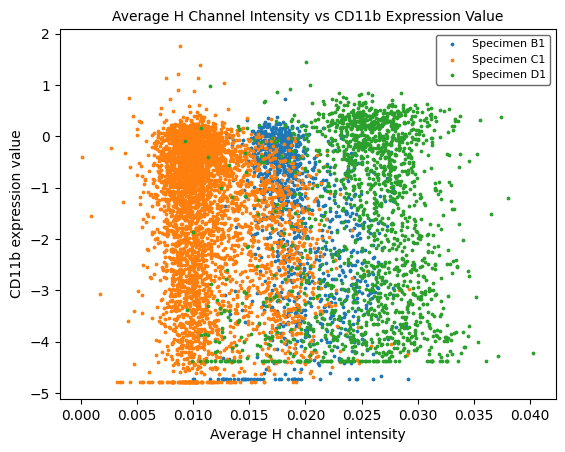

In [12]:
plt.figure()
ax = plt.gca()

ax.scatter(average_hs[b_indices], cd11b_values[b_indices], s=3, label='Specimen B1')
ax.scatter(average_hs[c_indices], cd11b_values[c_indices], s=3, label='Specimen C1')
ax.scatter(average_hs[d_indices], cd11b_values[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average H channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average H Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

In [13]:


print(spearmanr(average_hs, cd11b_values).statistic)
print(pearsonr(average_hs, cd11b_values).statistic)

-0.05841380665141695
-0.07349653751906055


There is a very weak negative correlation between the H-channel intensity and the CD11b expression. H-channel intensity is unlikely to have much predictive power for CD11b expression. It explains very little variance in the expression. 

0.2288638686327423
0.27776240426021365


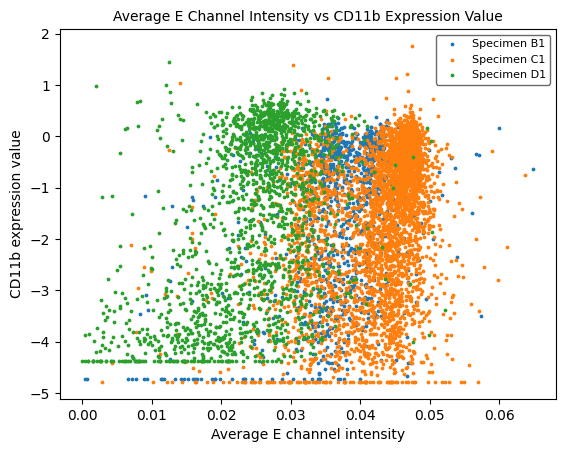

In [14]:
plt.figure()
ax = plt.gca()

ax.scatter(average_es[b_indices], cd11b_values[b_indices], s=3, label='Specimen B1')
ax.scatter(average_es[c_indices], cd11b_values[c_indices], s=3, label='Specimen C1')
ax.scatter(average_es[d_indices], cd11b_values[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average E channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average E Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(spearmanr(average_es, cd11b_values).statistic)
print(pearsonr(average_es, cd11b_values).statistic)

There is a weak, but stronger, positive correlation between the E channel and the CD11b expression value. The E channel average may help to predict the CD11b expression. However, there is still a lot of unexplained variance. 

## <a id='toc1_5_'></a>[v) Blue vs H Channels](#toc0_)

0.3878013601645221
0.367405687588898


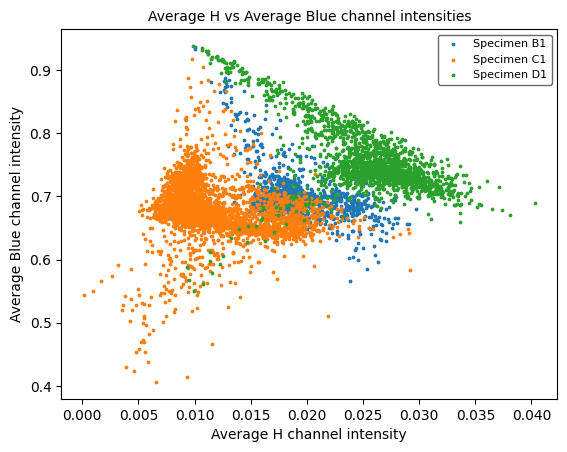

In [15]:
plt.figure()
ax = plt.gca()

ax.scatter(average_hs[b_indices], average_bs[b_indices], s=3, label='Specimen B1')
ax.scatter(average_hs[c_indices], average_bs[c_indices], s=3, label='Specimen C1')
ax.scatter(average_hs[d_indices], average_bs[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average H channel intensity')
ax.set_ylabel('Average Blue channel intensity')
ax.set_title('Average H vs Average Blue channel intensities', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(spearmanr(average_hs, average_bs).statistic)
print(pearsonr(average_hs, average_bs).statistic)

We can see that the H channel is able to partially separate out the three specimens, whereas the blue channel is much less able to do this. We can also see that there is some correlation between the H and Blue channels, but it is highly non-linear, which is due to the fact that the H channel is also influenced by the red and green channels. However, we can see that there are limits as to what blue values can be converted to what H values, and the shape roughly appears triangular in the scatter diagram. For example, there are no examples where an average blue channel of 0.9 correlates to an average H channel of 0.3. 

We can check for association between protein expression levels by finding the pairwise correlations of each. You can see the result below, with red colours indicating a higher correlation between the proteins. It is evident that there is association between protein expression levels of some pairs of proteins. For example, MET and PDGFRa are quite positively correlated. In fact, the correlations are mostly positvie. There are some pairs that are weakly negatively correlated. 

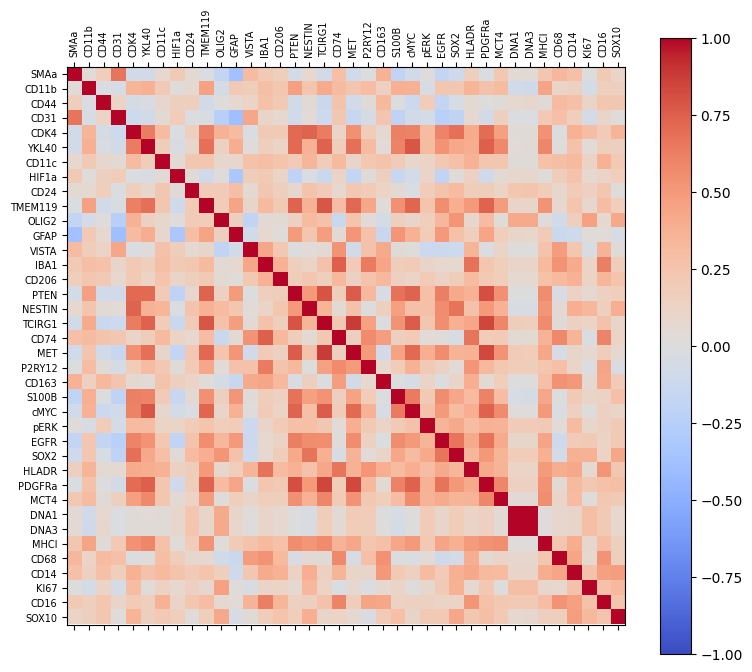

In [16]:
corr = df_train[protein_names].corr()

plt.figure(figsize=[9, 8])
ax = plt.gca()
corr_ax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(corr_ax)
ticks = np.arange(0, len(protein_names))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(protein_names, fontsize=7, rotation=90)
ax.set_yticklabels(protein_names, fontsize=7);

# <a id='toc2_'></a>[Question 2](#toc0_)

## <a id='toc2_1_'></a>[i) Feature Selection](#toc0_)

### <a id='toc2_1_1_'></a>[PCA On all RGB Channels](#toc0_)

In [81]:
from sklearn.decomposition import PCA
import cv2

# Resize function
def resize_images(X, new_size=(128, 128)):
    """Resizes all images in X to new_size."""
    n_train, _, _, c = X.shape  # Get original shape
    X_resized = np.zeros((n_train, new_size[0], new_size[1], c), dtype=X.dtype)

    for i in range(n_train):
        X_resized[i] = cv2.resize(X[i], new_size, interpolation=cv2.INTER_AREA)  # Use INTER_AREA for downscaling
    
    return X_resized

X = np.array(list(training_images.values()))
print(np.max(X[d_indices,:,:,2]))

# Apply resizing
X_resized = resize_images(X)

n_train, width, height, c = X_resized.shape
X_HED = np.zeros_like(X_resized)
for i in range(X.shape[0]):
    X_HED[i] = rgb2hed(X_resized[i])

1.0


Using the first image as an example

### <a id='toc2_1_2_'></a>[PCA on all HED channels](#toc0_)

(0.0, 1.0)

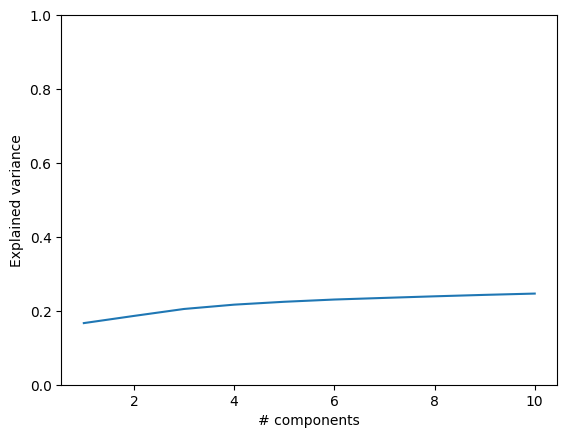

In [24]:
pca = PCA(10)
pcs = pca.fit_transform(X_resized.reshape((X_resized.shape[0]), -1))

plt.plot(np.arange(1, pca.n_components_ + 1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('# components')
plt.ylabel('Explained variance')
plt.ylim([0, 1])

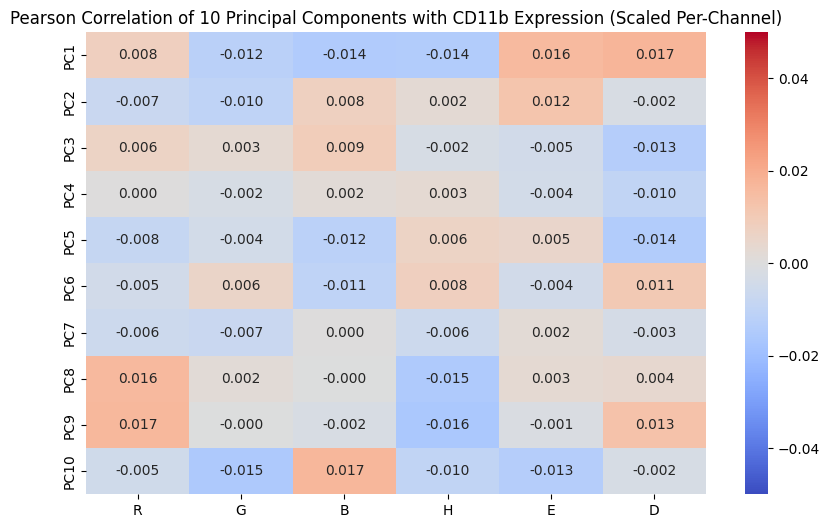

In [25]:
# Set number of principal components to keep
n_components = 10  # Change this to any desired number of PCs

# Function to scale each channel separately
def scale_all_channels(X):
    """Scales each image channel independently to zero mean, unit variance."""
    n_train, h, w, c = X.shape
    X_scaled = np.zeros((n_train, h*w*c))  # Reshape to [n_train, pixels, channels]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.reshape(n_train, -1))  # Scale each channel separately
    
    return X_scaled.reshape(n_train, -1)  # Flatten back into [n_train, features]

# Apply per-channel scaling
#X_rgb_scaled = scale_all_channels(X)  # Scale RGB channels independently
#X_hed_scaled = scale_all_channels(X_HED)  # Scale HED channels independently

# Scale individual channels separately before PCA
def scale_single_channel(X_channel):
    """Scales a single-channel image dataset."""
    scaler = StandardScaler()
    return scaler.fit_transform(X_channel.reshape(n_train, -1))

X_r_scaled = scale_single_channel(X_resized[..., 0])
X_g_scaled = scale_single_channel(X_resized[..., 1])
X_b_scaled = scale_single_channel(X_resized[..., 2])
X_h_scaled = scale_single_channel(X_HED[..., 0])
X_e_scaled = scale_single_channel(X_HED[..., 1])
X_d_scaled = scale_single_channel(X_HED[..., 2])

# Perform PCA with a variable number of components
def apply_pca(X_flat):
    return PCA(n_components=n_components).fit_transform(X_flat)

pca_results = {
    #"RGB": apply_pca(X_rgb_scaled),
    #"HED": apply_pca(X_hed_scaled),
    "R": apply_pca(X_r_scaled),
    "G": apply_pca(X_g_scaled),
    "B": apply_pca(X_b_scaled),
    "H": apply_pca(X_h_scaled),
    "E": apply_pca(X_e_scaled),
    "D": apply_pca(X_d_scaled),
}

def compute_pearson(pca_result):
    return [pearsonr(pca_result[:, i], df_train["CD11b"])[0] for i in range(pca_result.shape[1])]

correlations = {key: compute_pearson(pca) for key, pca in pca_results.items()}

# Convert to DataFrame
df_corr = pd.DataFrame(correlations, index=[f"PC{i+1}" for i in range(n_components)])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-0.05, vmax=0.05)
plt.title(f"Pearson Correlation of {n_components} Principal Components with CD11b Expression (Scaled Per-Channel)")
plt.show()


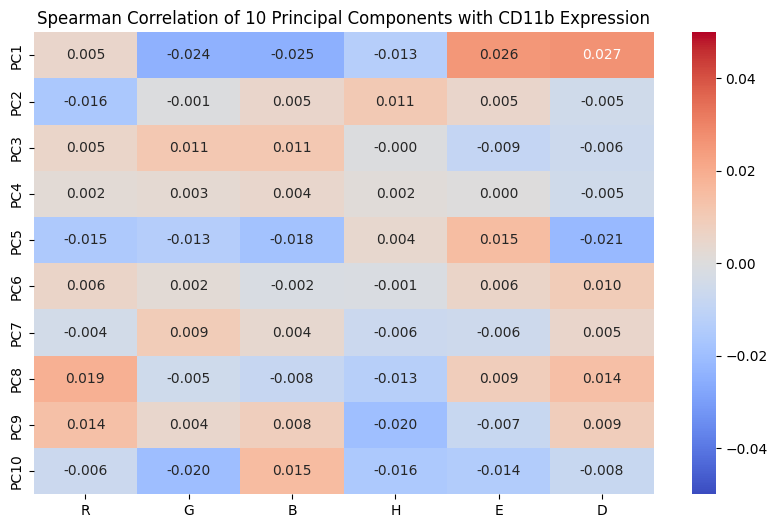

In [26]:
# Compute Pearson correlation with CD11b expression
def compute_spearman(pca_result):
    return [spearmanr(pca_result[:, i], df_train["CD11b"])[0] for i in range(pca_result.shape[1])]

correlations = {key: compute_spearman(pca) for key, pca in pca_results.items()}

# Convert to DataFrame
df_corr = pd.DataFrame(correlations, index=[f"PC{i+1}" for i in range(n_components)])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-0.05, vmax=0.05)
plt.title(f"Spearman Correlation of {n_components} Principal Components with CD11b Expression")
plt.show()

### <a id='toc2_1_3_'></a>[Mean and Variance](#toc0_)

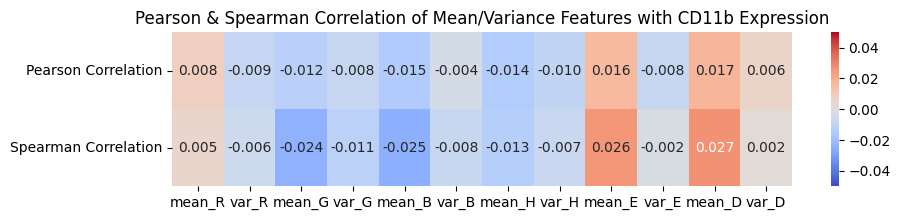

In [28]:
features = {
    "mean_R": np.mean(X[..., 0], axis=(1, 2)),  # Mean of Red channel
    "var_R": np.var(X[..., 0], axis=(1, 2)),    # Variance of Red channel
    "mean_G": np.mean(X[..., 1], axis=(1, 2)),  # Green
    "var_G": np.var(X[..., 1], axis=(1, 2)),    
    "mean_B": np.mean(X[..., 2], axis=(1, 2)),  # Blue
    "var_B": np.var(X[..., 2], axis=(1, 2)),    
    "mean_H": np.mean(X_HED[..., 0], axis=(1, 2)),   # H
    "var_H": np.var(X_HED[..., 0], axis=(1, 2)),
    "mean_E": np.mean(X_HED[..., 1], axis=(1, 2)),   # E
    "var_E": np.var(X_HED[..., 1], axis=(1, 2)),
    "mean_D": np.mean(X_HED[..., 2], axis=(1, 2)),   # D
    "var_D": np.var(X_HED[..., 2], axis=(1, 2)),
}

# Convert to DataFrame
df_features = pd.DataFrame(features)

# Compute Pearson correlation with CD11b
pearson_corr = df_features.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_features.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine both Pearson and Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Reshape to table format (transpose for better readability)
df_corr_table = df_corr.T

# Plot heatmap
color_scale = 0.05  # Adjust for better visualization
plt.figure(figsize=(10, 2))
sns.heatmap(df_corr_table, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Pearson & Spearman Correlation of Mean/Variance Features with CD11b Expression")
plt.show()

### <a id='toc2_1_4_'></a>[Histogram of Gradients](#toc0_)

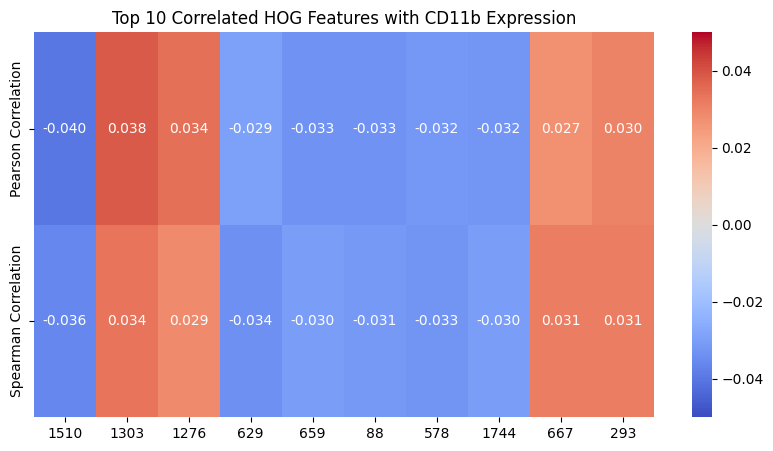

In [85]:
# Parameters for HOG
hog_params = {
    "orientations": 9,      # Number of gradient orientations
    "pixels_per_cell": (16, 16),  # Size of cell (smaller captures more local details)
    "cells_per_block": (2, 2),  # Number of cells in each block
    "feature_vector": True  # Flatten features
}

# Compute HOG features for each image
hog_features = []
for img in X_resized:
    gray_img = rgb2gray(img)  # Convert RGB to grayscale
    hog_vector = hog(gray_img, **hog_params)  # Compute HOG
    hog_features.append(hog_vector)

# Convert to DataFrame
df_hog = pd.DataFrame(hog_features)

# Compute Pearson and Spearman correlations
pearson_corr = df_hog.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_hog.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine Pearson & Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Select top 10 most correlated (absolute values)
df_corr["Max Abs Corr"] = df_corr.abs().max(axis=1)
df_corr_top10 = df_corr.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df_corr_top10.T, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Top 10 Correlated HOG Features with CD11b Expression")
plt.show()

### <a id='toc2_1_5_'></a>[PCA with HoG](#toc0_)

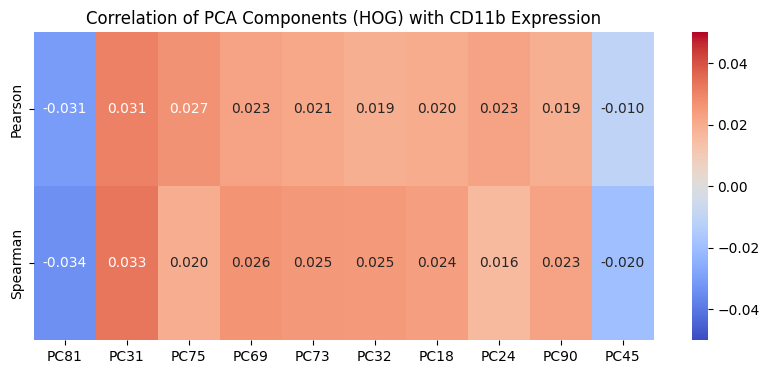

In [92]:
scaler = StandardScaler()

df_hog_scaled = scaler.fit_transform(df_hog)

# Step 1: Ensure HOG features are in a 2D array
n_components = 100  # Adjust based on variance explained
pca = PCA(n_components=n_components)
hog_pca = pca.fit_transform(df_hog_scaled)  # Transformed HOG features

# Convert to DataFrame
df_hog_pca = pd.DataFrame(hog_pca, columns=[f"PC{i+1}" for i in range(n_components)])

# Step 2: Compute Pearson and Spearman correlations with CD11b
pearson_corrs = df_hog_pca.apply(lambda col: pearsonr(col, df_train["CD11b"])[0])
spearman_corrs = df_hog_pca.apply(lambda col: spearmanr(col, df_train["CD11b"])[0])

# Step 3: Combine results into a table
corr_df = pd.DataFrame({
    "Pearson": pearson_corrs,
    "Spearman": spearman_corrs
})

# Select top 10 most correlated (absolute values)
corr_df["Max Abs Corr"] = corr_df.abs().max(axis=1)
df_corr_top10 = corr_df.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Step 4: Plot heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_corr_top10.T, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-color_scale, vmax=color_scale)
plt.title("Correlation of PCA Components (HOG) with CD11b Expression")
plt.show()

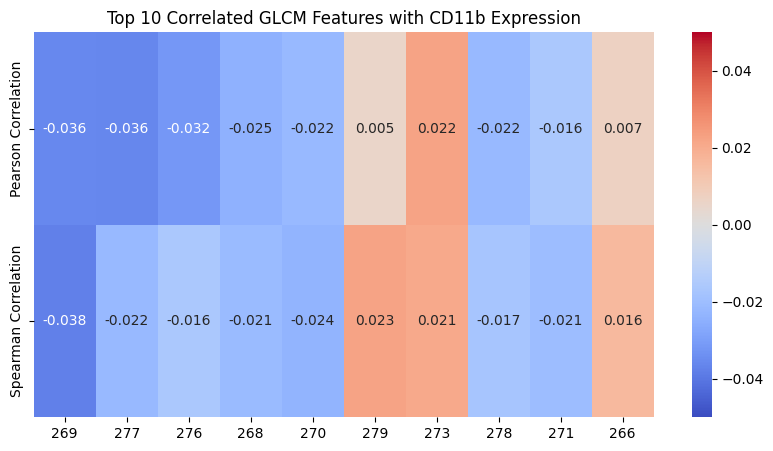

In [91]:
# Parameters for GLCM
glcm_params = {
    "distances": [1,2,4,8,16,32,64] ,     # Pixel displacements
    "angles": np.pi/8 * np.arange(8)  # Angles
}

# Compute HOG features for each image
glcm_features = []
for img in X_resized:
    gray_img = rgb2gray(img)  # Convert RGB to grayscale
    glcm = graycomatrix((255 * gray_img).astype(np.uint8), **glcm_params)  # Compute HOG
    glcm_vector = []
    glcm_vector.append(graycoprops(glcm, 'contrast'))
    glcm_vector.append(graycoprops(glcm, 'dissimilarity'))
    glcm_vector.append(graycoprops(glcm, 'homogeneity'))
    glcm_vector.append(graycoprops(glcm, 'energy'))
    glcm_vector.append(graycoprops(glcm, 'correlation'))
    glcm_features.append(np.array(glcm_vector).flatten())

# Convert to DataFrame
df_glcm = pd.DataFrame(glcm_features)

# Compute Pearson and Spearman correlations
pearson_corr = df_glcm.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_glcm.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine Pearson & Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Select top 10 most correlated (absolute values)
df_corr["Max Abs Corr"] = df_corr.abs().max(axis=1)
df_corr_top10 = df_corr.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df_corr_top10.T, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Top 10 Correlated GLCM Features with CD11b Expression")
plt.show()

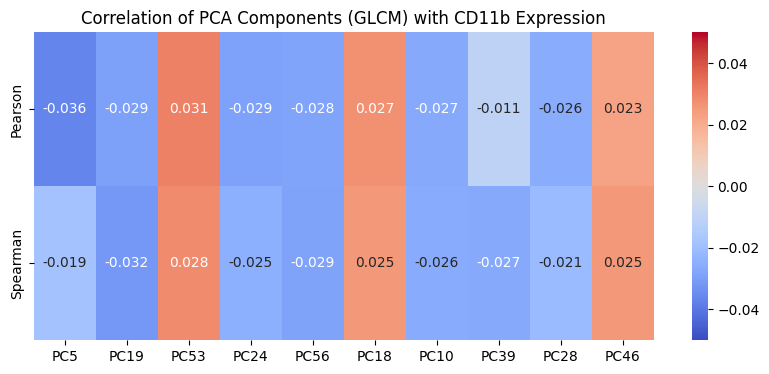

In [ ]:
scaler = StandardScaler()

df_glcm_scaled = scaler.fit_transform(df_glcm)

# Step 1: Ensure HOG features are in a 2D array
n_components = 100  # Adjust based on variance explained
pca = PCA(n_components=n_components)
hog_glcm = pca.fit_transform(df_glcm_scaled)  # Transformed HOG features

# Convert to DataFrame
df_glcm_pca = pd.DataFrame(hog_glcm, columns=[f"PC{i+1}" for i in range(n_components)])

# Step 2: Compute Pearson and Spearman correlations with CD11b
pearson_corrs = df_glcm_pca.apply(lambda col: pearsonr(col, df_train["CD11b"])[0])
spearman_corrs = df_glcm_pca.apply(lambda col: spearmanr(col, df_train["CD11b"])[0])

# Step 3: Combine results into a table
corr_df = pd.DataFrame({
    "Pearson": pearson_corrs,
    "Spearman": spearman_corrs
})

# Select top 10 most correlated (absolute values)
corr_df["Max Abs Corr"] = corr_df.abs().max(axis=1)
df_corr_top10 = corr_df.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Step 4: Plot heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_corr_top10.T, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-color_scale, vmax=color_scale)
plt.title("Correlation of PCA Components (GLCM) with CD11b Expression")
plt.show()

## <a id='toc2_2_'></a>[Regression Models](#toc0_)

### Linear Regression

Fold 1: MSE = 2.1716, R² = -0.0354


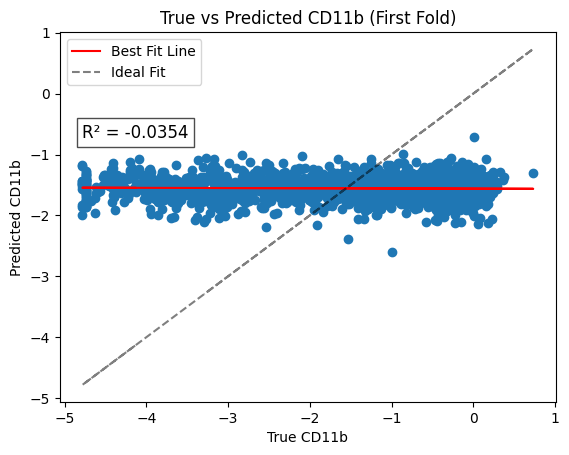

Fold 2: MSE = 1.7048, R² = -0.0471
Fold 3: MSE = 1.8991, R² = -0.1719
Fold 4: MSE = 2.5365, R² = -0.0308
Fold 5: MSE = 3.0214, R² = -0.0458


In [102]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

kf = KFold(n_splits=5)
i=0

df_features = pd.concat([df_glcm, df_hog], axis=1)

model = LinearRegression()
pipeline = make_pipeline(StandardScaler(), PCA(n_components=100), model)

for train, test in kf.split(X_resized):
    X_train = df_features.iloc[train]
    X_test = df_features.iloc[test]

    y_train = df_train['CD11b'].iloc[train]
    y_test = df_train['CD11b'].iloc[test]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Compute scores
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Fold {i+1}: MSE = {mse:.4f}, R² = {r2:.4f}")

    if i == 0:
        plt.scatter(y_test, y_pred)

        # Fit line of best fit
        coeffs = np.polyfit(y_test, y_pred, 1)
        poly_eq = np.poly1d(coeffs)
        plt.plot(y_test, poly_eq(y_test), color="red", label="Best Fit Line")

        # Plot identity line (y = x)
        plt.plot(y_test, y_test, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

        # Add text with R² score
        plt.text(min(y_test), max(y_pred), f"R² = {r2:.4f}", fontsize=12, ha="left", bbox=dict(facecolor="white", alpha=0.7))

        # Labels and title
        plt.xlabel("True CD11b")
        plt.ylabel("Predicted CD11b")
        plt.title("True vs Predicted CD11b (First Fold)")
        plt.legend()
        plt.show()

    i += 1

### Random Forest

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5)
i=0

df_features = pd.concat([df_glcm, df_hog], axis=1)

rf = RandomForestRegressor()
pipeline = make_pipeline(StandardScaler(), PCA(n_components=100), rf)

for train, test in kf.split(X_resized):
    X_train = df_features.iloc[train]
    X_test = df_features.iloc[test]

    y_train = df_train['CD11b'].iloc[train]
    y_test = df_train['CD11b'].iloc[test]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Compute scores
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Fold {i+1}: MSE = {mse:.4f}, R² = {r2:.4f}")

    if i == 0:
        plt.scatter(y_test, y_pred)

        # Fit line of best fit
        coeffs = np.polyfit(y_test, y_pred, 1)
        poly_eq = np.poly1d(coeffs)
        plt.plot(y_test, poly_eq(y_test), color="red", label="Best Fit Line")

        # Plot identity line (y = x)
        plt.plot(y_test, y_test, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

        # Add text with R² score
        plt.text(min(y_test), max(y_pred), f"R² = {r2:.4f}", fontsize=12, ha="left", bbox=dict(facecolor="white", alpha=0.7))

        # Labels and title
        plt.xlabel("True CD11b")
        plt.ylabel("Predicted CD11b")
        plt.title("True vs Predicted CD11b (First Fold)")
        plt.legend()
        plt.show()

    i += 1

KeyboardInterrupt: 

In [113]:
rf = RandomForestRegressor()

parameters = {'criterion': ["squared_error", "friedman_mse"], 'max_depth': [10, 25, 50], 'n_estimators': [10, 50, 100]}
scoring = ['neg_root_mean_squared_error', 'r2']
clf = GridSearchCV(rf, parameters, cv=KFold(n_splits=5), refit=False, scoring=scoring, verbose=10)

num_components = 75

# We want to perform scaling and PCA in the pipeline so as to avoid data leakage during cross-validation
pipeline = make_pipeline(StandardScaler(), PCA(10), clf)
pipeline.fit(df_features, df_train['CD11b'])

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV 1/5; 1/18] START criterion=squared_error, max_depth=10, n_estimators=10.....
[CV 1/5; 1/18] END criterion=squared_error, max_depth=10, n_estimators=10; neg_root_mean_squared_error: (test=-1.479) r2: (test=-0.043) total time=   0.4s
[CV 2/5; 1/18] START criterion=squared_error, max_depth=10, n_estimators=10.....
[CV 2/5; 1/18] END criterion=squared_error, max_depth=10, n_estimators=10; neg_root_mean_squared_error: (test=-1.312) r2: (test=-0.057) total time=   0.3s
[CV 3/5; 1/18] START criterion=squared_error, max_depth=10, n_estimators=10.....
[CV 3/5; 1/18] END criterion=squared_error, max_depth=10, n_estimators=10; neg_root_mean_squared_error: (test=-1.391) r2: (test=-0.194) total time=   0.3s
[CV 4/5; 1/18] START criterion=squared_error, max_depth=10, n_estimators=10.....
[CV 4/5; 1/18] END criterion=squared_error, max_depth=10, n_estimators=10; neg_root_mean_squared_error: (test=-1.600) r2: (test=-0.040) total time=   

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=10)),
                ('gridsearchcv',
                 GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=RandomForestRegressor(),
                              param_grid={'criterion': ['squared_error',
                                                        'friedman_mse'],
                                          'max_depth': [10, 25, 50],
                                          'n_estimators': [10, 50, 100]},
                              refit=False,
                              scoring=['neg_root_mean_squared_error', 'r2'],
                              verbose=10))])

In [117]:
# Get table of parameters
params = [[params['criterion'], params['max_depth'], params['n_estimators']] for params in clf.cv_results_['params']] 

keys = ['mean_test_neg_root_mean_squared_error', 'std_test_neg_root_mean_squared_error', 'mean_test_r2', 'std_test_r2']

# Get table of results
results = np.array([clf.cv_results_.get(key) for key in keys])

# Format the metrics for the table and create columns
keys = [key.replace('test_', '').replace('_', ' ') for key in keys]
columns = ['criterion', 'max_depth', 'n_estimators'] + keys

# Create the final table and dataframe
table = np.hstack([params, results.T])
df = pd.DataFrame(table, columns=columns)
df[keys] = df[keys].astype(float).round(3)
df.iloc[df[['mean neg root mean squared error', 'mean r2']].idxmax()]

,criterion,max_depth,n_estimators,mean neg root mean squared error,std neg root mean squared error,mean r2,std r2
11,friedman_mse,10,100,-1.491,0.155,-0.056,0.048
11,friedman_mse,10,100,-1.491,0.155,-0.056,0.048


### SVC 

Fold 1: MSE = 2.5161, R² = -0.1996


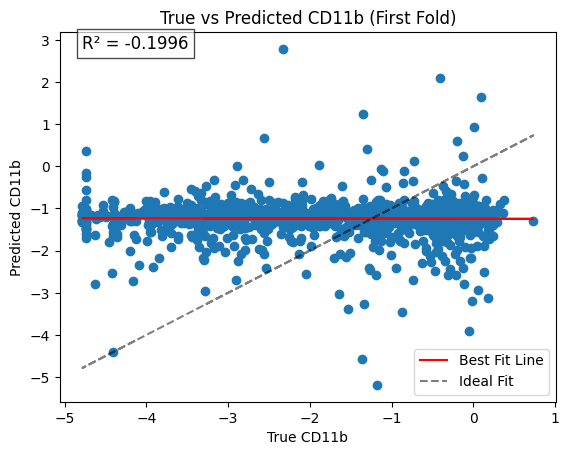

Fold 2: MSE = 1.7786, R² = -0.0924
Fold 3: MSE = 1.8685, R² = -0.1530
Fold 4: MSE = 3.0163, R² = -0.2258
Fold 5: MSE = 3.4452, R² = -0.1925


In [120]:
from sklearn.model_selection import KFold
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5)
i=0

df_features = pd.concat([df_glcm, df_hog], axis=1)

svr = SVR(kernel='poly')
pipeline = make_pipeline(StandardScaler(), PCA(n_components=100), svr)

for train, test in kf.split(X_resized):
    X_train = df_features.iloc[train]
    X_test = df_features.iloc[test]

    y_train = df_train['CD11b'].iloc[train]
    y_test = df_train['CD11b'].iloc[test]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Compute scores
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Fold {i+1}: MSE = {mse:.4f}, R² = {r2:.4f}")

    if i == 0:
        plt.scatter(y_test, y_pred)

        # Fit line of best fit
        coeffs = np.polyfit(y_test, y_pred, 1)
        poly_eq = np.poly1d(coeffs)
        plt.plot(y_test, poly_eq(y_test), color="red", label="Best Fit Line")

        # Plot identity line (y = x)
        plt.plot(y_test, y_test, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

        # Add text with R² score
        plt.text(min(y_test), max(y_pred), f"R² = {r2:.4f}", fontsize=12, ha="left", bbox=dict(facecolor="white", alpha=0.7))

        # Labels and title
        plt.xlabel("True CD11b")
        plt.ylabel("Predicted CD11b")
        plt.title("True vs Predicted CD11b (First Fold)")
        plt.legend()
        plt.show()

    i += 1

In [121]:
parameters = {'kernel': ['rbf'], 'C': np.logspace(-1, 2, 10), 'gamma': np.logspace(-4, -1, 10)}
scoring = ['neg_root_mean_squared_error', 'r2']
svr = SVR()
clf = GridSearchCV(svr, parameters, cv=KFold(n_splits=5), refit=False, scoring=scoring, verbose=10)

# We can use a pipeline to carry out scaling at each fold. This is better than carrying out scaling 
# on the entire dataset first, as that would mean the validation data influences the training data. 

num_components = 75

# We want to perform scaling and PCA in the pipeline so as to avoid data leakage during cross-validation
pipeline = make_pipeline(StandardScaler(), PCA(n_components=num_components), clf)
pipeline.fit(df_features, df_train['CD11b'])

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START C=0.1, gamma=0.0001, kernel=rbf...........................
[CV 1/5; 1/100] END C=0.1, gamma=0.0001, kernel=rbf; neg_root_mean_squared_error: (test=-1.557) r2: (test=-0.155) total time=   1.5s
[CV 2/5; 1/100] START C=0.1, gamma=0.0001, kernel=rbf...........................
[CV 2/5; 1/100] END C=0.1, gamma=0.0001, kernel=rbf; neg_root_mean_squared_error: (test=-1.293) r2: (test=-0.026) total time=   1.5s
[CV 3/5; 1/100] START C=0.1, gamma=0.0001, kernel=rbf...........................
[CV 3/5; 1/100] END C=0.1, gamma=0.0001, kernel=rbf; neg_root_mean_squared_error: (test=-1.285) r2: (test=-0.020) total time=   1.5s
[CV 4/5; 1/100] START C=0.1, gamma=0.0001, kernel=rbf...........................
[CV 4/5; 1/100] END C=0.1, gamma=0.0001, kernel=rbf; neg_root_mean_squared_error: (test=-1.698) r2: (test=-0.172) total time=   1.5s
[CV 5/5; 1/100] START C=0.1, gamma=0.0001, kernel=rbf...........................


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=75)),
                ('gridsearchcv',
                 GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=SVR(),
                              param_grid={'C': array([  0.1       ,   0.21544347,   0.46415888,   1.        ,
         2.15443469,   4.64158883,  10.        ,  21.5443469 ,
        46.41588834, 100.        ]),
                                          'gamma': array([0.0001    , 0.00021544, 0.00046416, 0.001     , 0.00215443,
       0.00464159, 0.01      , 0.02154435, 0.04641589, 0.1       ]),
                                          'kernel': ['rbf']},
                              refit=False,
                              scoring=['neg_root_mean_squared_error', 'r2'],
                              verbose=10))])

In [123]:
# Get table of parameters
params = [[params['kernel'], params['C'], params['gamma']] for params in clf.cv_results_['params']] 

keys = ['mean_test_neg_root_mean_squared_error', 'std_test_neg_root_mean_squared_error', 'mean_test_r2', 'std_test_r2']

# Get table of results
results = np.array([clf.cv_results_.get(key) for key in keys])

# Format the metrics for the table and create columns
keys = [key.replace('test_', '').replace('_', ' ') for key in keys]
columns = ['kernel', 'C', 'gamma'] + keys

# Create the final table and dataframe
table = np.hstack([params, results.T])
df = pd.DataFrame(table, columns=columns)
df[keys] = df[keys].astype(float).round(3)
df.iloc[df[['mean neg root mean squared error', 'mean r2']].idxmax()]

,kernel,C,gamma,mean neg root mean squared error,std neg root mean squared error,mean r2,std r2
46,rbf,2.1544346900318834,0.01,-1.483,0.163,-0.044,0.041
46,rbf,2.1544346900318834,0.01,-1.483,0.163,-0.044,0.041
